In [1]:
import numpy as np
import random
import os
from skimage.io import imread 
import matplotlib.pyplot as plt
from main.BatchGeneratorTripletLoss import BatchGenerator
from tensorflow import keras
from keras import layers, models, metrics, optimizers
from keras.applications import densenet, DenseNet121
from keras import ops
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import pickle
from scipy.spatial import distance
import main.Metrics as eval
import seaborn as sns
import pandas as pd

In [2]:
NUM_IMGS = 5000 # It was stopped at epoch 2500 more or less
INPUT = (112, 112, 3)

path_images = "./Practicum/dcface_0.5m_oversample_xid/dcface_0.5m_oversample_xid/images/"

In [3]:
data_files_train = [[path_images + str(id), id] for id in range(NUM_IMGS)]
batch_gen_train = BatchGenerator(data_files_train, batch_size = 128, dim = INPUT)

data_files_val = [[path_images + str(id), id] for id in range(NUM_IMGS, NUM_IMGS + 200)]
batch_gen_val = BatchGenerator(data_files_val, batch_size = 128, dim = INPUT)

In [ ]:
#batch_gen_train.__getitem__(0)

## Model

In [3]:
base_cnn = DenseNet121(
    weights="imagenet", input_shape=INPUT, include_top=False
)

flatten = layers.Flatten()(base_cnn.output)
dense1 = layers.Dense(512, activation="relu")(flatten)
dense1 = layers.BatchNormalization()(dense1)
dense2 = layers.Dense(256, activation="relu")(dense1)
dense2 = layers.BatchNormalization()(dense2)
output = layers.Dense(256)(dense2)

embedding = models.Model(base_cnn.input, output, name="Embedding")

trainable = False
for layer in base_cnn.layers:
    if layer.name == "conv5_block1_out":
        trainable = True
    layer.trainable = trainable

In [4]:
class DistanceLayer(layers.Layer):
    """
    This layer is responsible for computing the distance between the anchor
    embedding and the positive embedding, and the anchor embedding and the
    negative embedding.
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, anchor, positive, negative):
        ap_distance = ops.sum(tf.square(anchor - positive), -1)
        an_distance = ops.sum(tf.square(anchor - negative), -1)
        return (ap_distance, an_distance)


anchor_input = layers.Input(name="anchor", shape=INPUT)
positive_input = layers.Input(name="positive", shape=INPUT)
negative_input = layers.Input(name="negative", shape=INPUT)

distances = DistanceLayer()(
    embedding(densenet.preprocess_input(anchor_input)),
    embedding(densenet.preprocess_input(positive_input)),
    embedding(densenet.preprocess_input(negative_input)),
)

siamese_network = models.Model(
    inputs=[anchor_input, positive_input, negative_input], outputs=distances
)

In [5]:
class SiameseModel(models.Model):
    """The Siamese Network model with a custom training and testing loops.

    Computes the triplet loss using the three embeddings produced by the
    Siamese Network.

    The triplet loss is defined as:
       L(A, P, N) = max(‖f(A) - f(P)‖² - ‖f(A) - f(N)‖² + margin, 0)
    """

    def __init__(self, siamese_network, margin=0.5):
        super().__init__()
        self.siamese_network = siamese_network
        self.margin = margin
        self.loss_tracker = metrics.Mean(name="loss")

    def call(self, inputs):
        return self.siamese_network(inputs)

    def train_step(self, data):
        # GradientTape is a context manager that records every operation that
        # you do inside. We are using it here to compute the loss so we can get
        # the gradients and apply them using the optimizer specified in
        # `compile()`.
        with tf.GradientTape() as tape:
            loss = self._compute_loss(data)

        # Storing the gradients of the loss function with respect to the
        # weights/parameters.
        gradients = tape.gradient(loss, self.siamese_network.trainable_weights)

        # Applying the gradients on the model using the specified optimizer
        self.optimizer.apply_gradients(
            zip(gradients, self.siamese_network.trainable_weights)
        )

        # Let's update and return the training loss metric.
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def test_step(self, data):
        loss = self._compute_loss(data)

        # Let's update and return the loss metric.
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

    def _compute_loss(self, data):
        # The output of the network is a tuple containing the distances
        # between the anchor and the positive example, and the anchor and
        # the negative example.
        ap_distance, an_distance = self.siamese_network(data)

        # Computing the Triplet Loss by subtracting both distances and
        # making sure we don't get a negative value.
        loss = ap_distance - an_distance
        loss = tf.maximum(loss + self.margin, 0.0)
        return loss

    @property
    def metrics(self):
        # We need to list our metrics here so the `reset_states()` can be
        # called automatically.
        return [self.loss_tracker]

In [6]:
# Model
siamese_model = SiameseModel(siamese_network)

In [9]:
# Compile the model
siamese_model.compile(optimizer=optimizers.Adam(0.0001))

In [7]:
filepath="model_tripletloss_v2.keras"
checkpoint = ModelCheckpoint(filepath, 
                             monitor = 'val_loss', 
                             verbose = 1,
                             save_best_only = True, 
                             mode = 'min')

In [ ]:
# Training
siamese_model.fit(
    batch_gen_train, 
    epochs = 5000, 
    validation_data = batch_gen_val,
    callbacks = checkpoint)

Epoch 1/5000


/opt/homebrew/Caskroom/miniconda/base/envs/env_practicum/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.4984
Epoch 1: val_loss improved from inf to 0.47619, saving model to model_tripletloss.keras


/opt/homebrew/Caskroom/miniconda/base/envs/env_practicum/lib/python3.12/site-packages/keras/src/saving/saving_api.py:102: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


19/19 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step - loss: 0.4984 - val_loss: 0.4762
Epoch 2/5000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.4903
Epoch 2: val_loss did not improve from 0.47619
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - loss: 0.4902 - val_loss: 0.4810
Epoch 3/5000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.4787
Epoch 3: val_loss did not improve from 0.47619
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - loss: 0.4785 - val_loss: 0.4907
Epoch 4/5000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.4751
Epoch 4: val_loss did not improve from 0.47619
19/19 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - loss: 0.4752 - val_loss: 0.4901
Epoch 5/5000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.4573
Epoch 5: val_loss did not improve from 0.47619
19/19 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - loss: 0.4576 - val_loss: 0.4897
Epoch 6/5000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.4534
Epoch 6: val_loss did not improve from 0.47619
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - loss: 0.4537 - val_loss: 0.47

...

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 227s/step - loss: 0.3224  
Epoch 239: val_loss did not improve from 0.27011
19/19 ━━━━━━━━━━━━━━━━━━━━ 7310s 263s/step - loss: 0.3225 - val_loss: 0.3415
Epoch 240/5000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - loss: 0.3322 
Epoch 240: val_loss did not improve from 0.27011
19/19 ━━━━━━━━━━━━━━━━━━━━ 220s 12s/step - loss: 0.3321 - val_loss: 0.3591
Epoch 241/5000


2024-07-15 09:25:33.083511: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 7 of 8
2024-07-15 09:25:34.807682: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 0.3364
Epoch 241: val_loss did not improve from 0.27011
19/19 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - loss: 0.3362 - val_loss: 0.3377
Epoch 242/5000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.3346
Epoch 242: val_loss did not improve from 0.27011
19/19 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - loss: 0.3346 - val_loss: 0.3983
Epoch 243/5000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.3262
Epoch 243: val_loss did not improve from 0.27011
19/19 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - loss: 0.3261 - val_loss: 0.3649
Epoch 244/5000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.3354
Epoch 244: val_loss did not improve from 0.27011
19/19 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - loss: 0.3353 - val_loss: 0.3077
Epoch 245/5000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.3250
Epoch 245: val_loss did not improve from 0.27011
19/19 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - loss: 0.3251 - val_loss: 0.3285
Epoch 246/5000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.33

2024-07-15 10:15:57.453848: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 4 of 8
2024-07-15 10:16:35.424149: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 5 of 8
2024-07-15 10:17:07.403651: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 6 of 8
2024-07-15 10:17:24.334084: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 7 of 8
2024-07-15 10:17:25.468866: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.3286
Epoch 298: val_loss did not improve from 0.26739
19/19 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - loss: 0.3287 - val_loss: 0.2985
Epoch 299/5000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.3254
Epoch 299: val_loss did not improve from 0.26739
19/19 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - loss: 0.3256 - val_loss: 0.3216
Epoch 300/5000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.3312
Epoch 300: val_loss did not improve from 0.26739
19/19 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - loss: 0.3314 - val_loss: 0.3454
Epoch 301/5000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.3172
Epoch 301: val_loss did not improve from 0.26739
19/19 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - loss: 0.3172 - val_loss: 0.3391
Epoch 302/5000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.3171
Epoch 302: val_loss did not improve from 0.26739
19/19 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - loss: 0.3173 - val_loss: 0.3009
Epoch 303/5000
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.3

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## Predict

In [7]:
filepath = "./models/model_tripletloss_v2.keras"
siamese_model.load_weights(filepath)

In [8]:
with open('test_data.pkl', 'rb') as f:
    (true_pairs, true_pairs_1_test, true_pairs_2_test, false_pairs, false_pairs_1_test, false_pairs_2_test) = pickle.load(f)

In [9]:
# Getting the embedding layer
layer_name = 'Embedding'
emb_layer_model = models.Model(inputs = siamese_model.siamese_network.get_layer(layer_name).input,
                                 outputs = siamese_model.siamese_network.get_layer(layer_name).output)


In [10]:
pred_true_pairs_1 = emb_layer_model.predict(true_pairs_1_test)
pred_true_pairs_2 = emb_layer_model.predict(true_pairs_2_test)

pred_false_pairs_1 = emb_layer_model.predict(false_pairs_1_test)
pred_false_pairs_2 = emb_layer_model.predict(false_pairs_2_test)

16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 673ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 448ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 444ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 443ms/step


In [11]:
real_test = np.concatenate((np.ones(len(true_pairs)), np.zeros(len(false_pairs))))

true_preds = [1 - distance.cosine(pred_true_pairs_1[i], pred_true_pairs_2[i]) for i in range(len(pred_true_pairs_2))]
false_preds = [1 - distance.cosine(pred_false_pairs_1[i], pred_false_pairs_2[i]) for i in range(len(pred_false_pairs_2))]

pred_test = np.concatenate((np.asarray(true_preds), np.asarray(false_preds)))

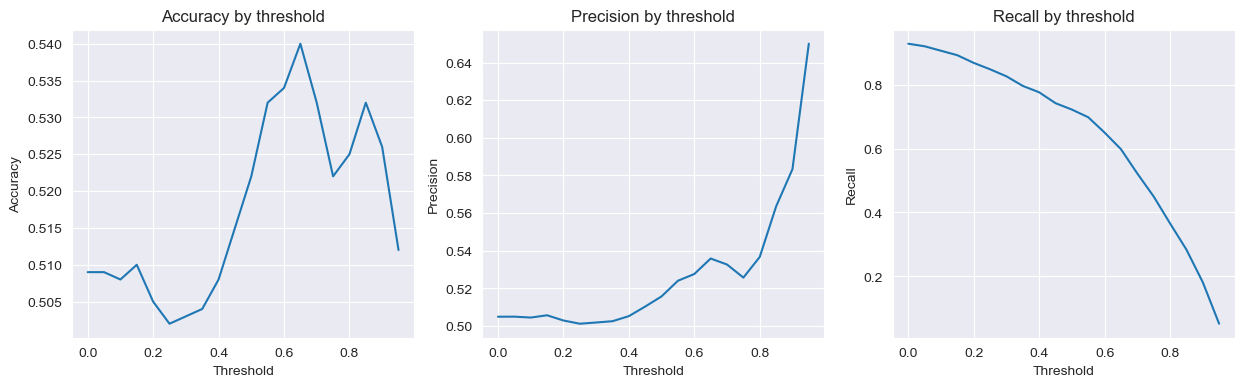

In [12]:
# Accuracy, precision and recall
sns.set_style('darkgrid')
eval.plt_metrics_thr(real_test, pred_test)


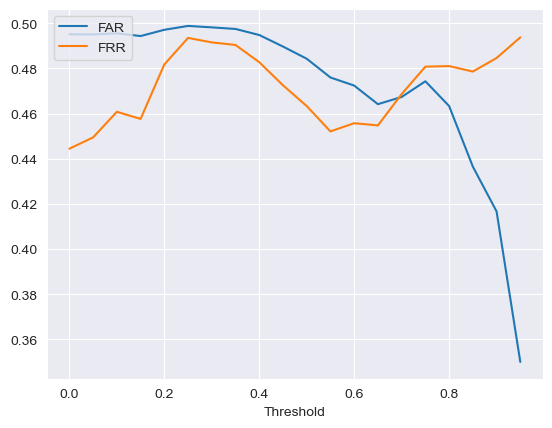

In [13]:
# FAR and FRR
eval.plot_far_frr(real_test, pred_test)

In [15]:
# False Acceptance Rate and False Rejection Rate
threshold, acc, precision, recall, FAR, FRR= eval.all_metrics(real_test, pred_test)
pd.DataFrame({'threshold': threshold, 'Accuracy': acc, 'Precision': precision, 'Recall': recall, 'FAR': FAR, 'FRR': FRR})

,threshold,Accuracy,Precision,Recall,FAR,FRR
0,0.0,0.509,0.504897,0.928,0.495103,0.444444
1,0.1,0.508,0.504454,0.906,0.495546,0.460784
2,0.2,0.505,0.502897,0.868,0.497103,0.481752
3,0.3,0.503,0.501823,0.826,0.498177,0.491525
4,0.4,0.508,0.505208,0.776,0.494792,0.482759
5,0.5,0.522,0.515714,0.722,0.484286,0.463333
6,0.6,0.534,0.527597,0.650,0.472403,0.455729
7,0.7,0.532,0.532653,0.522,0.467347,0.468627
8,0.8,0.525,0.536657,0.366,0.463343,0.481032
9,0.9,0.526,0.583333,0.182,0.416667,0.484597


Acuraccy: 0.505
Precision: 0.503
Recall: 0.868


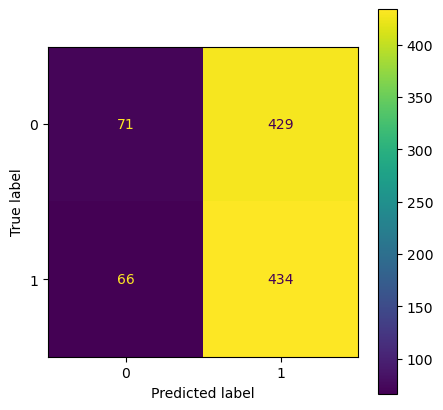

In [25]:
sns.reset_orig()

pred_thr_test = eval.pred_threshold(pred_test, thr = 0.2)
eval.plt_cm_metrics(real_test, pred_thr_test)

Acuraccy: 0.508
Precision: 0.505
Recall: 0.776


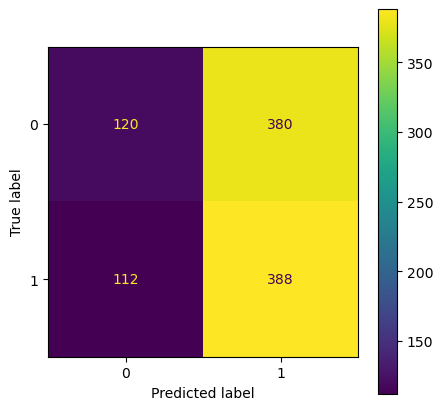

In [26]:
pred_thr_test = eval.pred_threshold(pred_test, thr = 0.4)
eval.plt_cm_metrics(real_test, pred_thr_test)

Acuraccy: 0.525
Precision: 0.537
Recall: 0.366


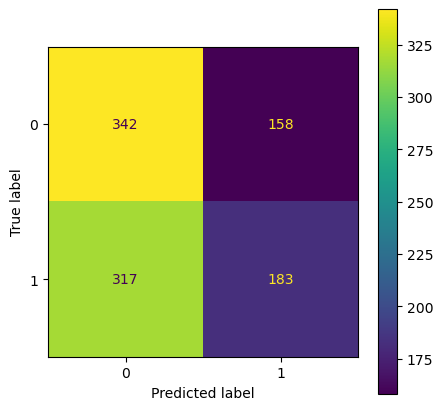

In [27]:
pred_thr_test = eval.pred_threshold(pred_test, thr = 0.8)
eval.plt_cm_metrics(real_test, pred_thr_test)

Acuraccy: 0.526
Precision: 0.583
Recall: 0.182


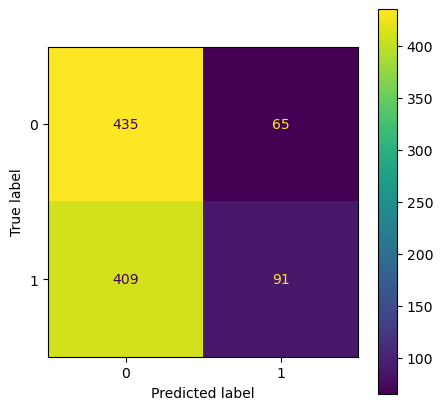

In [28]:
pred_thr_test = eval.pred_threshold(pred_test, thr = 0.9)
eval.plt_cm_metrics(real_test, pred_thr_test)